# Trial extraction of features for Bachelor's Thesis Project

## MFCC Features 

### Trial from Geek for Geeks

Audio file loading and waveform visualization.

https://www.geeksforgeeks.org/nlp/mel-frequency-cepstral-coefficients-mfcc-for-speech-recognition/

In [2]:
import random
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
import numpy as np
import librosa.display
import IPython.display as ipd

### Check the sampling rate 

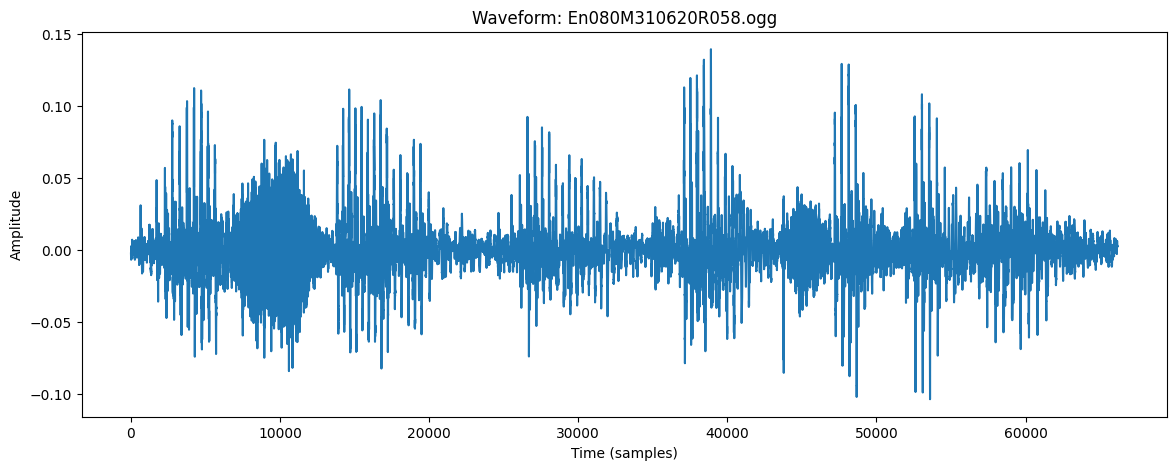

Sampling rate: 48000


In [3]:
# Original sampling rate 

data_dir = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/TESDHE/Speech Signals")

audio_files = [p for p in data_dir.iterdir() if p.suffix.lower() == ".ogg"]

sample_path = audio_files[0] # to visualize the first file

y, sr = librosa.load(str(sample_path), sr=None)  # or omit sr=None for default resampling
plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title(f"Waveform: {sample_path.name}")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()
print("Sampling rate:", sr)

"sampling rate is fs = 16 000 samples per second, which is a standard value used in speech processing since it corresponds to wideband (8 kHz) representation of speech that faithfully restores all frequency components of the speech signal (Usman et al., 2018). As most of the salient features of speech lie within
the 8 kHz bandwidth, increasing the sampling rate beyond 16000 samples per second leads to a point of diminishing returns while increasing the length of data
leading to increased computational complexity. " Usman et al 2021 (Heartrate estimation...)

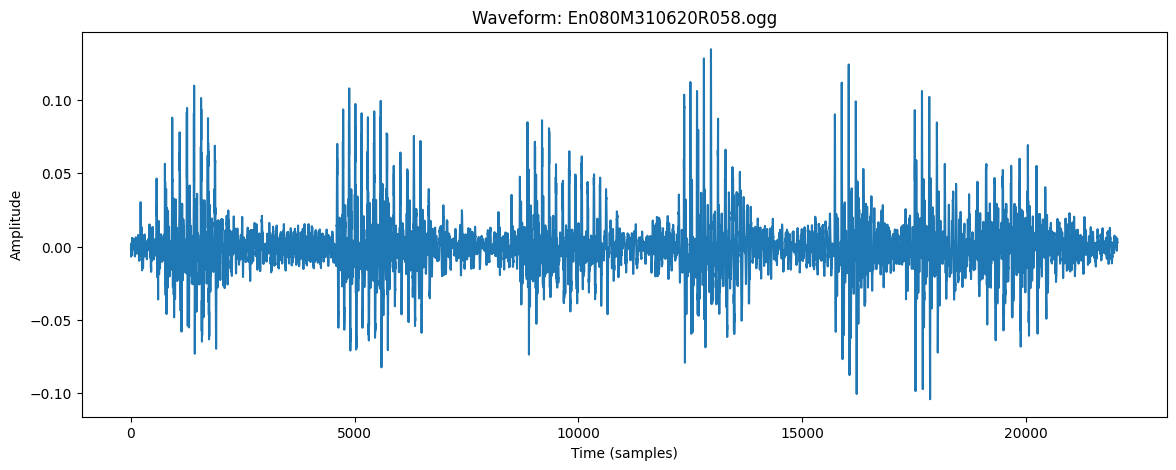

In [4]:
# Sampling rate = 16kHz
y, sr = librosa.load(str(sample_path), sr=16000)  # from Usman


plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title(f"Waveform: {sample_path.name}")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()

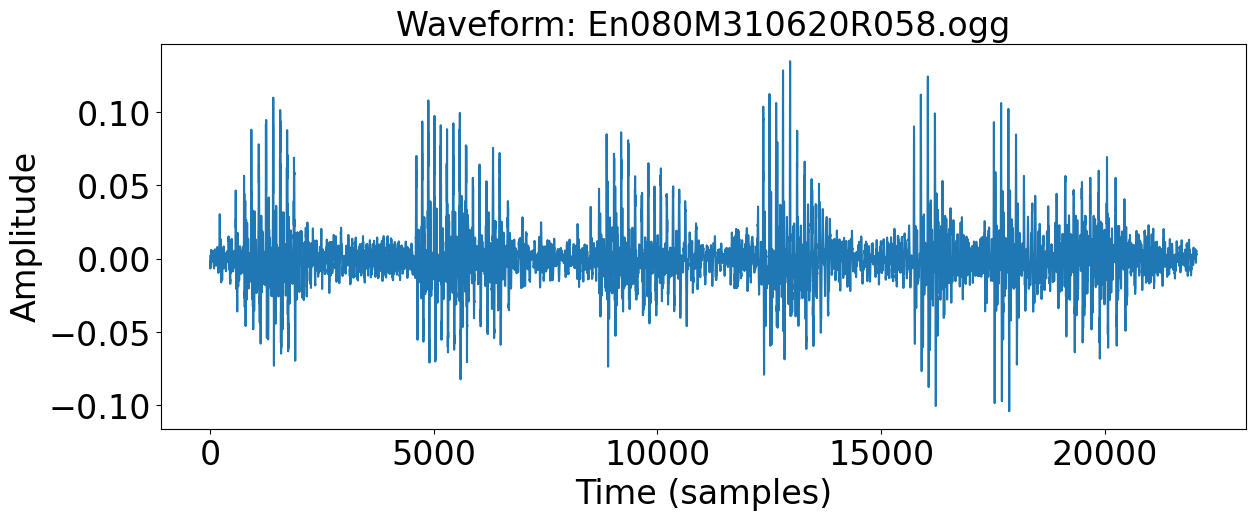

In [6]:
# Sr = 16kHz, bigger font
y, sr = librosa.load(str(sample_path), sr=16000)  # from Usman

plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title(f"Waveform: {sample_path.name}", fontsize=24)
plt.xlabel("Time (samples)", fontsize=24)
plt.ylabel("Amplitude", fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.show()

In [7]:
ipd.Audio(sample_path)

### Pre-emphasis - SKIP

"Pre-emphasizing the audio signal helps to balance the spectrum by amplifying higher frequencies."

Gonna test with and without it - original doesnt use it but its influence is unknown 

"Preemphasis is a process to boost the magnitude of higher frequencies in the signal for improving the Signal to Noise ratio. It is the initial step of noise reduction technique [9]. The recorded emotional speech is emphasized by passing through a filter to increase the magnitude of the higher frequencies of the speech signal.

Y[n] = X[n] - 0.95X[n-1]

Let a = 0.95, which makes 95 % of any one sample is presumed to originate from previous sample [9]." 

(Heart rate monitoring using human speech spectral features)

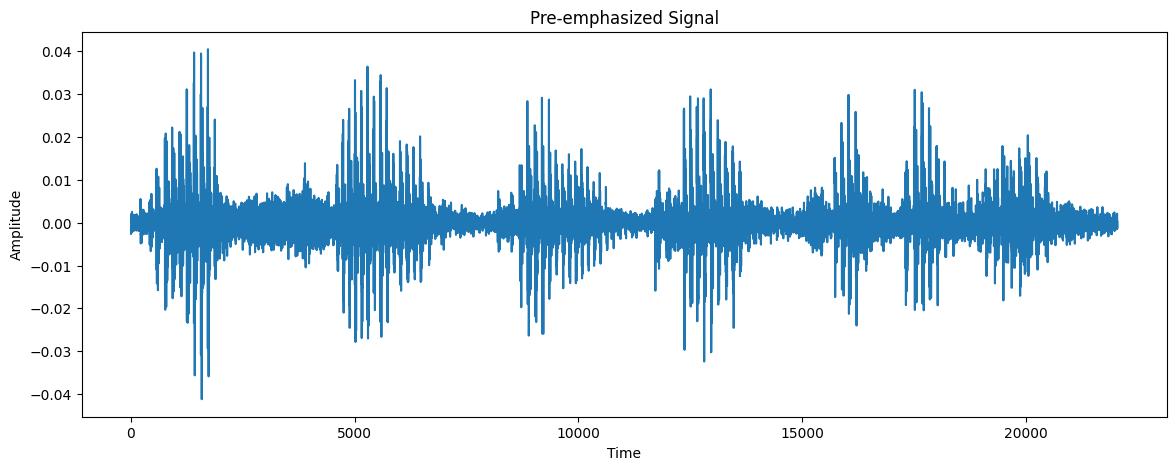

In [8]:
# Apply pre-emphasis filter
pre_emphasis = 0.95
y_preemphasized = librosa.effects.preemphasis(y = y, coef=pre_emphasis)

# Plot the pre-emphasized signal
plt.figure(figsize=(14, 5))
plt.plot(y_preemphasized)
plt.title('Pre-emphasized Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

In [9]:
ipd.Audio(y_preemphasized, rate=sr)

### Framing

Breaking the signal into small frames to capture the temporal characteristics of the signal.

"Framing is the process of segmentation of speech samples originated from analog to digital converter into small frames. The speech signal is divided into frames of N samples. Neighboring frames are separated based on the value M and  where M = 100 and N = 256 [9]."

Samples per frame: 320
Frame step in samples: 160
Number of frames: 136
Shape of frames array: (136, 320)


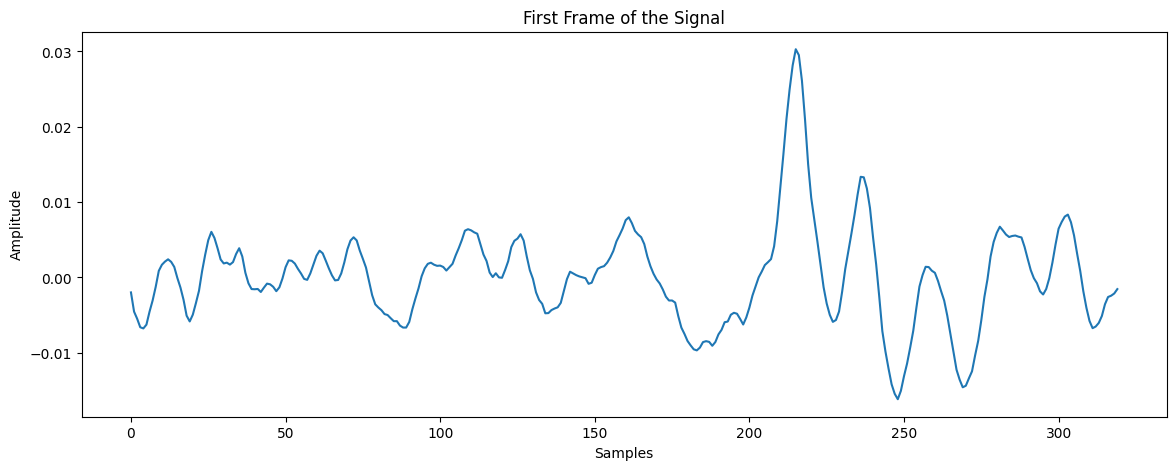

In [10]:
frame_size = 0.020  # 20 ms
frame_stride = 0.01  # 10 ms
frame_length, frame_step = frame_size * sr, frame_stride * sr  # Convert from seconds to samples
signal_length = len(y)
frame_length = int(round(frame_length))
frame_step = int(round(frame_step))
num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))

# Pad signal to ensure all frames have equal number of samples
pad_signal_length = num_frames * frame_step + frame_length
z = np.zeros((pad_signal_length - signal_length))
pad_signal = np.append(y, z)

# Slice the signal into frames
indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
frames = pad_signal[indices.astype(np.int32, copy=False)]

print(f"Samples per frame: {frame_length}")
print(f"Frame step in samples: {frame_step}")
print(f"Number of frames: {num_frames}")
print(f"Shape of frames array: {frames.shape}")

# Plot a few frames
plt.figure(figsize=(14, 5))
plt.plot(frames[0])
plt.title('First Frame of the Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

In [11]:
ipd.Audio(frames[0], rate=sr)

### Windowing

Apply a window function to each frame to minimize discontinuities at the edges.

"Hamming windowing is one of the most simple window functions. It reduces the effect of leakage for the better representation of the frequency spectrum of the speech signals. The frames obtained are multiplied with the window function W(n) to reduce the discontinuities of the speech signals in the time domain. It helps in reducing the spectral artifacts of the speech signals. The window function can be denoted as W(n) [9].

W[n] = 0.56 - 0.46 cos ( (2*Pi*n) / N-1 ), 0 <= n <= N-1 

where, N is the number of samples per frame, Y[n] is the output signal, X(n) is the input signal, and W(n) is the Hamming window. The result of windowing signal can be represented as,

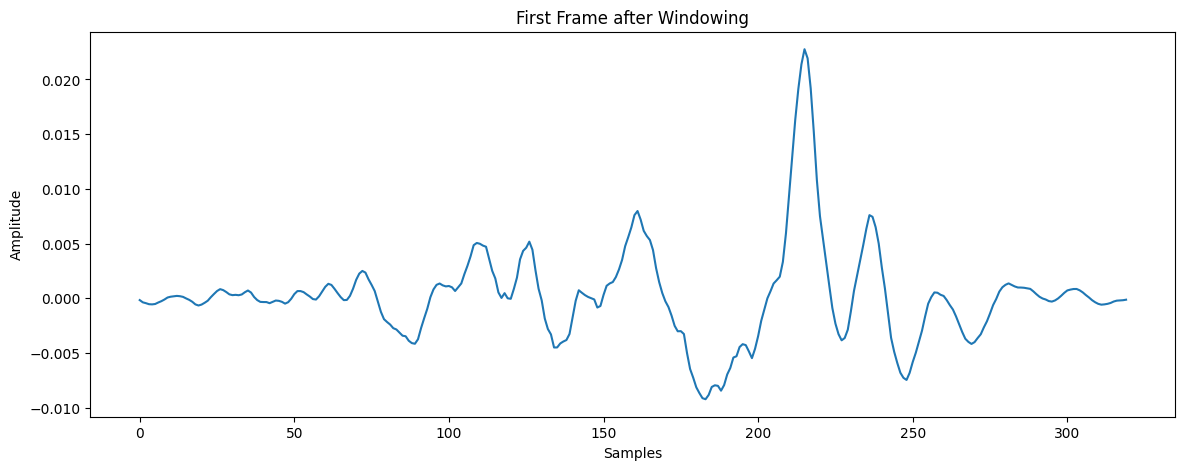

In [12]:
# Apply Hamming window
frames *= np.hamming(frame_length)

# Plot the first frame after windowing
plt.figure(figsize=(14, 5))
plt.plot(frames[0])
plt.title('First Frame after Windowing')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

In [13]:
ipd.Audio(frames[0], rate=sr)

### Fast Fourier Transform (FFT)

Convert each frame from the time domain to the frequency domain.

CONVERT HR to hertz and plot here

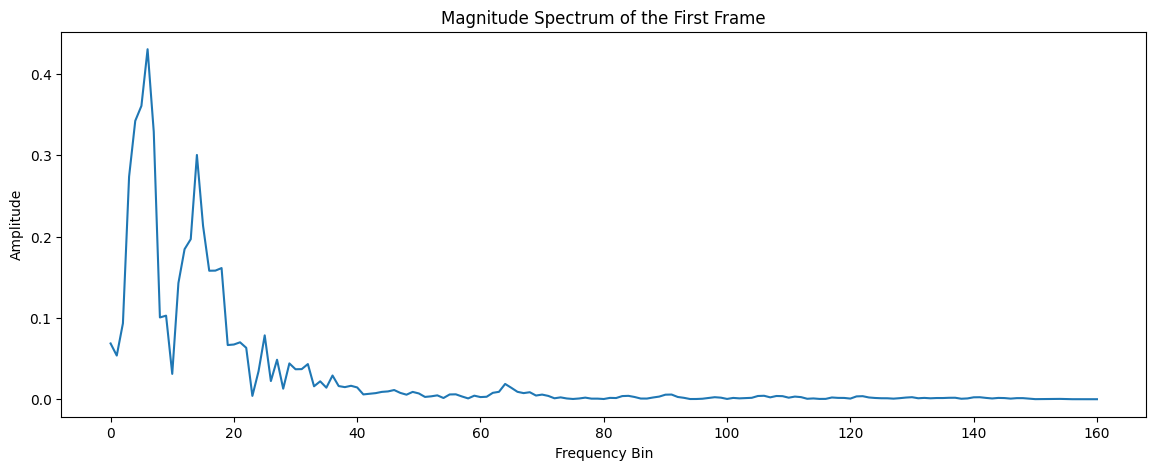

In [14]:
NFFT = 320 # num of samples in each frame
mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude of the FFT
energy_frames = mag_frames ** 2  # Energy Spectrum

# Plot the magnitude spectrum of the first frame
plt.figure(figsize=(14, 5))
plt.plot(mag_frames[0])
plt.title('Magnitude Spectrum of the First Frame')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')
plt.show()

In [15]:
ipd.Audio(mag_frames[0], rate=sr)

### Apply Mel-filterbank

Apply a filterbank to the power spectra to get the energy in each Mel-frequency bin.

[  0.   1.   3.   6.   8.  11.  14.  18.  22.  27.  32.  38.  45.  52.
  61.  70.  81.  93. 107. 123. 140. 160.]
Mel frequency range: 0.00 - 2835.00 mel
Hz frequency range: 0.00 - 8000.00 Hz


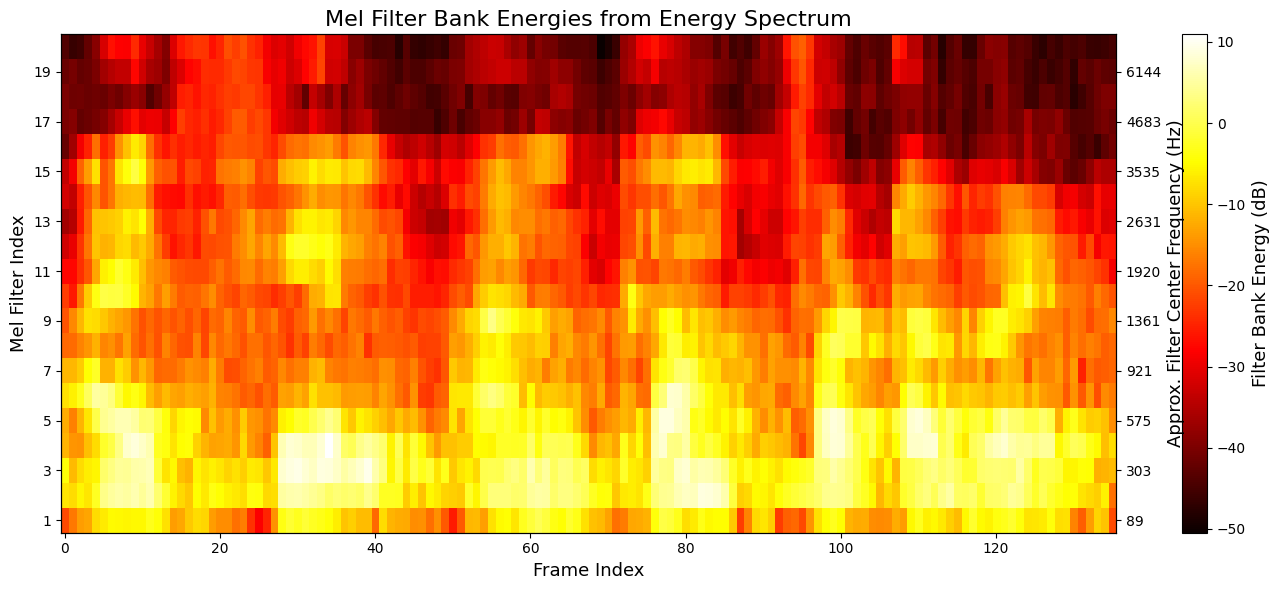

In [16]:
nfilt = 20
low_freq_mel = 0
high_freq_mel = 1125 * np.log(1 + (sr / 2) / 700)  # Convert Hz to Mel
mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
hz_points = 700 * (np.exp(mel_points / 1125) - 1)  # Convert Mel to Hz
bin = np.floor((NFFT + 1) * hz_points / sr)
print(bin)
fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
for m in range(1, nfilt + 1):
    f_m_minus = int(bin[m - 1])   # left
    f_m = int(bin[m])             # center
    f_m_plus = int(bin[m + 1])    # right

    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

# Apply Mel filters to ENERGY spectrum
filter_banks = np.dot(energy_frames, fbank.T)

# Numerical stability before log
filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)

# Log-compressed filter bank energies
filter_banks_db = 10 * np.log10(filter_banks)

print(f"Mel frequency range: {low_freq_mel:.2f} - {high_freq_mel:.2f} mel")
print(f"Hz frequency range: {hz_points[0]:.2f} - {hz_points[-1]:.2f} Hz")

center_hz = hz_points[1:-1]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    filter_banks_db.T,
    cmap='hot',
    aspect='auto',
    origin='lower'
)

ax.set_title('Mel Filter Bank Energies from Energy Spectrum', fontsize=16)
ax.set_xlabel('Frame Index', fontsize=13)
ax.set_ylabel('Mel Filter Index', fontsize=13)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Filter Bank Energy (dB)', fontsize=13)

ax.set_yticks(np.arange(0, nfilt, 2))
ax.set_yticklabels(np.arange(1, nfilt + 1, 2))

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
tick_positions = np.arange(0, nfilt, 2)
ax2.set_yticks(tick_positions)
ax2.set_yticklabels([f"{center_hz[i]:.0f}" for i in tick_positions])
ax2.set_ylabel('Approx. Filter Center Frequency (Hz)', fontsize=13)

plt.tight_layout()
plt.show()



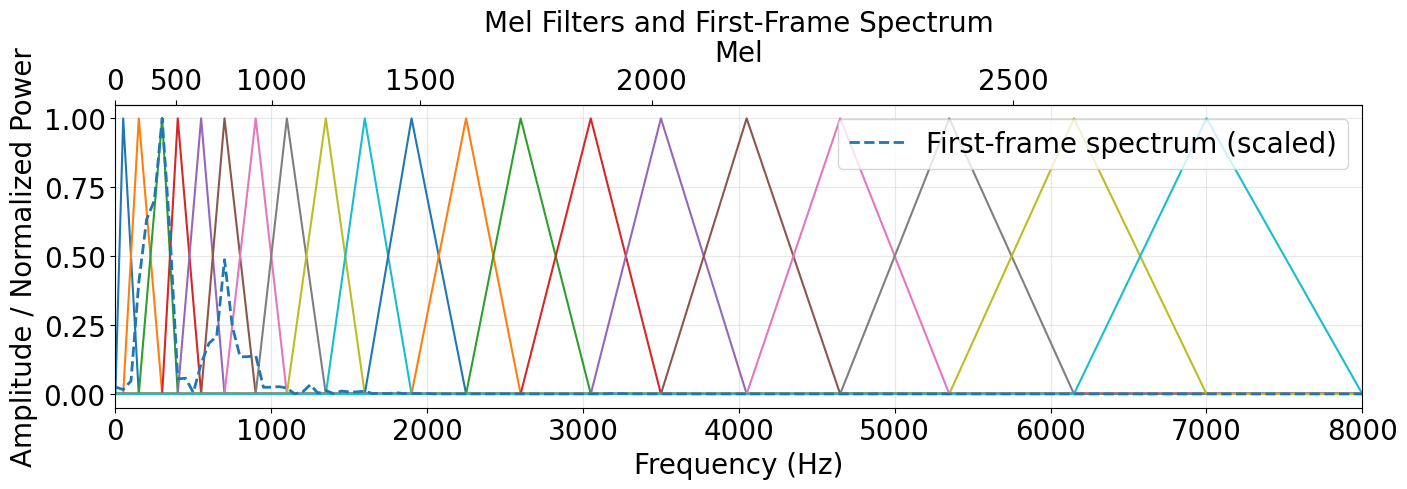

In [17]:
# Plot filters + one-frame spectrum in one figure
freqs_hz = np.linspace(0, sr / 2, int(np.floor(NFFT / 2 + 1)))
one_frame_spectrum = energy_frames[0]  # first frame
one_frame_spectrum_scaled = one_frame_spectrum / np.max(one_frame_spectrum)

fig, ax = plt.subplots(figsize=(14, 5))

# Plot triangular filters
for i in range(nfilt):
    ax.plot(freqs_hz, fbank[i], linewidth=1.5)

# Overlay one frame spectrum
ax.plot(
    freqs_hz,
    one_frame_spectrum_scaled,
    linestyle='--',
    linewidth=2,
    label='First-frame spectrum (scaled)'
)

ax.set_title('Mel Filters and First-Frame Spectrum', fontsize=20)
ax.set_xlabel('Frequency (Hz)', fontsize=20)
ax.set_ylabel('Amplitude / Normalized Power', fontsize=20)
ax.set_xlim(0, sr / 2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=20)
ax.tick_params(axis='both', labelsize=20)

# Add top axis in Mel
def hz_to_mel(f):
    return 1125 * np.log(1 + f / 700)

def mel_to_hz(m):
    return 700 * (np.exp(m / 1125) - 1)

secax = ax.secondary_xaxis('top', functions=(hz_to_mel, mel_to_hz))
secax.set_xlabel('Mel', fontsize=20)
secax.tick_params(axis='x', labelsize=20)

plt.tight_layout()
plt.show()

### Discrete Cosine Transform (DCT)

Apply DCT to the filter bank energies to get the MFCCs.

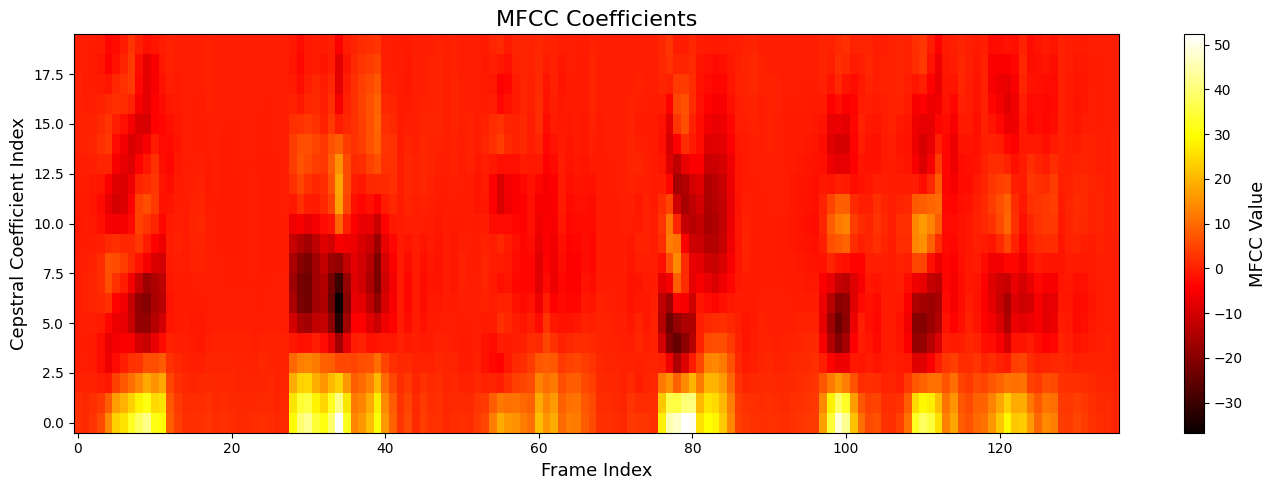

In [18]:
from scipy.fftpack import dct

num_ceps = 20
mfcc = dct(filter_banks, type=2, axis=1)[:, :num_ceps]

# Plot the MFCCs
plt.figure(figsize=(14, 5))
im = plt.imshow(
    mfcc.T,
    cmap='hot',
    aspect='auto',
    origin='lower'   
)

plt.title('MFCC Coefficients', fontsize=16)
plt.xlabel('Frame Index', fontsize=13)
plt.ylabel('Cepstral Coefficient Index', fontsize=13)

cbar = plt.colorbar(im)
cbar.set_label('MFCC Value', fontsize=13)

plt.tight_layout()
plt.show()

## Other speech features

Fundamental Frequency F0 = 1st harmonic

n=1

but unvoiced constants have no pitch eg "s"

ie F0 is not defined for constants without vocal fold vibration

there are also errors bc human gladdice cannot instantaneously reconfigure - but speech tends to be continuous (you can prioritize smoothness but can cause issues)

F0 can be perturbed by vocal tract constrictions, but humans dont perceive these as pitch dips

F0 != Pitch, it is only a proxy (not always the same)

  start_time   end_time      pitch  jitter_local  shimmer_local_db
0  00:00.000  00:00.020   0.000000      0.000000          0.000000
1  00:00.010  00:00.030   0.000000      0.000000          0.000000
2  00:00.020  00:00.040  21.760000      0.000000          5.454786
3  00:00.030  00:00.050  21.809999      0.000000          5.454786
4  00:00.040  00:00.060  21.980000      0.000000          4.357227
5  00:00.050  00:00.070  22.230000      0.021449          2.543511
6  00:00.060  00:00.080  22.480000      0.025262          0.991814
7  00:00.070  00:00.090  22.639999      0.023878          0.814816
8  00:00.080  00:00.100  22.700001      0.020772          1.075466
9  00:00.090  00:00.110  22.590000      0.021088          1.074183


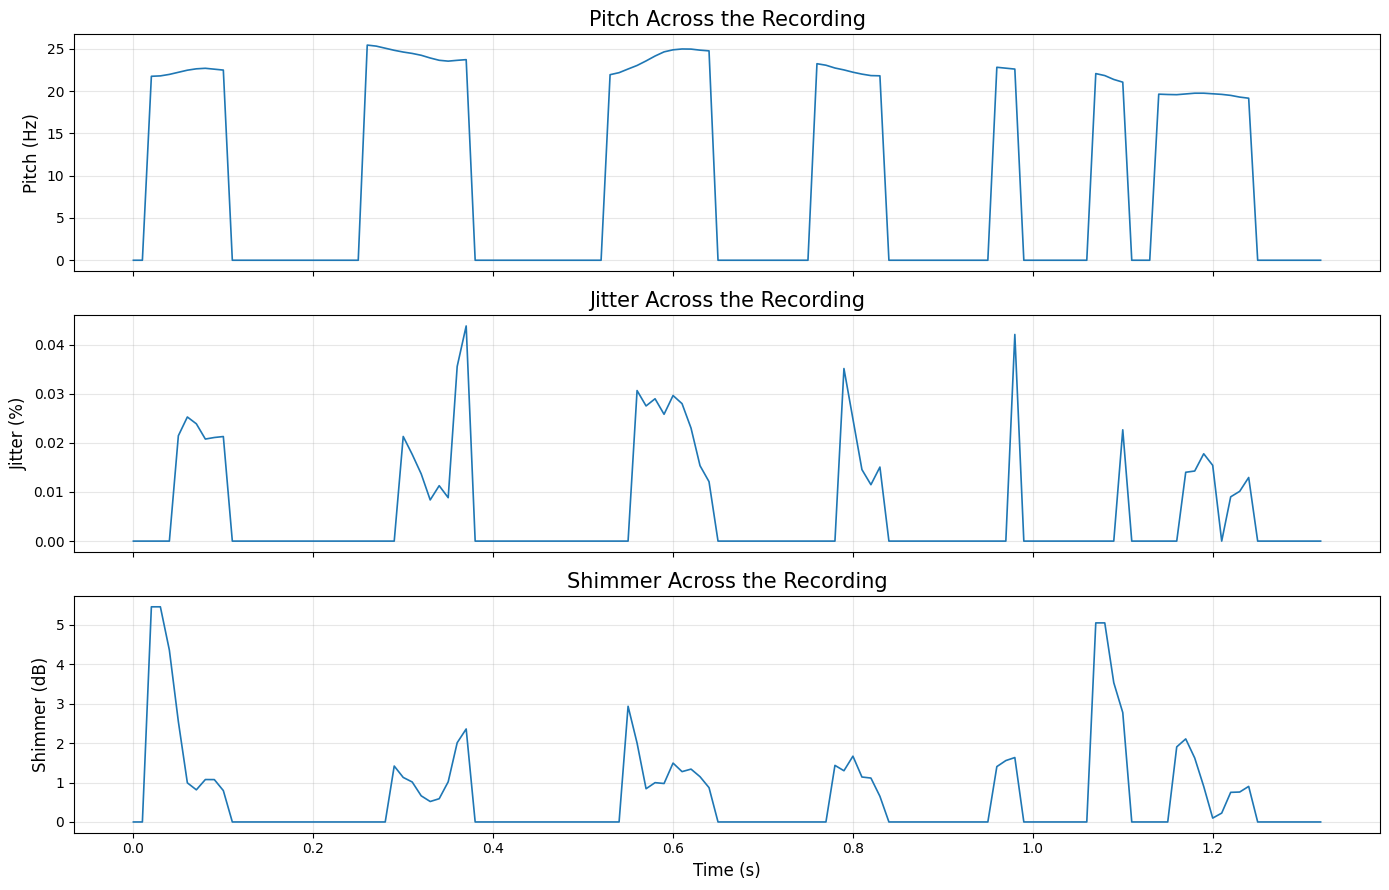

In [6]:
import opensmile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
data_dir = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/TESDHE/Speech Signals")
audio_files = [p for p in data_dir.iterdir() if p.suffix.lower() == ".ogg"]
sample_path = audio_files[0]
audio_path = str(sample_path)   
# ----------------------------
# Helper: format pandas Timedelta as MM:SS.mmm
# ----------------------------
def format_timedelta_mmss(td):
    if pd.isna(td):
        return None
    total_seconds = td.total_seconds()
    minutes = int(total_seconds // 60)
    seconds = total_seconds % 60
    return f"{minutes:02d}:{seconds:06.3f}"

# ----------------------------
# Extract low-level descriptors
# ----------------------------
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
    sampling_rate=16000,
    resample=True,
    options={"frameSize": 0.020, "frameStep": 0.010},   # 20 ms / 10 ms
)

df = smile.process_file(audio_path).reset_index()

# ----------------------------
# Column names
# ----------------------------
pitch_col = "F0semitoneFrom27.5Hz_sma3nz"
jitter_col = "jitterLocal_sma3nz"
shimmer_col = "shimmerLocaldB_sma3nz"

required_cols = ["start", "end", pitch_col, jitter_col, shimmer_col]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print("These requested columns were not found:")
    print(missing_cols)
    print("\nAvailable columns are:")
    print(df.columns.tolist())
else:
    df["pitch"] = df[pitch_col]

    # ----------------------------
    # Time columns for table and plotting
    # ----------------------------
    df["start_time"] = df["start"].apply(format_timedelta_mmss)
    df["end_time"] = df["end"].apply(format_timedelta_mmss)
    df["time_s"] = df["start"].dt.total_seconds()

    # ----------------------------
    # Final output table
    # ----------------------------
    output = df[
        [
            "start_time",
            "end_time",
            "pitch",
            jitter_col,
            shimmer_col,
        ]
    ].copy()

    output = output.rename(
        columns={
            jitter_col: "jitter_local",
            shimmer_col: "shimmer_local_db",
        }
    )

    output["pitch"] = output["pitch"].round(2)
    output["jitter_local"] = output["jitter_local"].round(6)
    output["shimmer_local_db"] = output["shimmer_local_db"].round(6)

    print(output.head(10))

    # ----------------------------
    # Plot whole recording
    # ----------------------------
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(df["time_s"], df["pitch"], linewidth=1.2)
    axes[0].set_title("Pitch Across the Recording", fontsize=15)
    axes[0].set_ylabel("Pitch (Hz)", fontsize=12)
    axes[0].grid(alpha=0.3)

    axes[1].plot(df["time_s"], df[jitter_col], linewidth=1.2)
    axes[1].set_title("Jitter Across the Recording", fontsize=15)
    axes[1].set_ylabel("Jitter (%)", fontsize=12)
    axes[1].grid(alpha=0.3)

    axes[2].plot(df["time_s"], df[shimmer_col], linewidth=1.2)
    axes[2].set_title("Shimmer Across the Recording", fontsize=15)
    axes[2].set_xlabel("Time (s)", fontsize=12)
    axes[2].set_ylabel("Shimmer (dB)", fontsize=12)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()